# American Option Pricing with QMC Methods

This notebook demonstrates pricing of an **American Put Option** using:

- Monte Carlo (IID)
- Quasi-Monte Carlo (Sobol, Halton, Lattice)
- Longstaff–Schwartz method for early exercise

We use a modified version of QMCPy installed via:

```python
pip install -e .
```

which includes a corrected implementation of Longstaff–Schwartz.

In [ ]:
from qmcpy.discrete_distribution import Sobol, IIDStdUniform, Halton, Lattice
from qmcpy.stopping_criterion import CubQMCSobolG, CubMCG, CubQMCLatticeG
from qmcpy.integrand.financial_option import FinancialOption

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ================================
# PROBLEM PARAMETERS
# ================================
d = 32
vol = 0.2
initPrice = 100
strike = 110
interest = 0.05
callput = "PUT"        # American PUT
t_final = 1.0

In [3]:
# ================================
# SAMPLERS
# ================================
SobolPoints     = Sobol(dimension=d)
IIDPoints       = IIDStdUniform(dimension=d)
HaltonPoints    = Halton(dimension=d)
SobolPointsRep  = Sobol(dimension=d, replications=16)
LatticePoints   = Lattice(dimension=d)

In [4]:
# ================================
# AMERICAN OPTIONS (FIXED)
# ================================
AmericanSobol = FinancialOption(
    SobolPoints,
    option="AMERICAN",   # ✅ FIXED
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

AmericanIID = FinancialOption(
    IIDPoints,
    option="AMERICAN",
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

AmericanHalton = FinancialOption(
    HaltonPoints,
    option="AMERICAN",
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

AmericanSobolRep = FinancialOption(
    SobolPointsRep,
    option="AMERICAN",
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

AmericanLattice = FinancialOption(
    LatticePoints,
    option="AMERICAN",   # ✅ FIXED
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

In [5]:
# ================================
# TOLERANCES
# ================================
tol_vec = np.array([0.5, 0.1, 0.05, 0.01, 0.005])

nSobol_required    = np.zeros_like(tol_vec)
tSobol_required    = np.zeros_like(tol_vec)

nIID_required      = np.zeros_like(tol_vec)
tIID_required      = np.zeros_like(tol_vec)

nHalton_required   = np.zeros_like(tol_vec)
tHalton_required   = np.zeros_like(tol_vec)

nSobolRep_required = np.zeros_like(tol_vec)
tSobolRep_required = np.zeros_like(tol_vec)

nLattice_required  = np.zeros_like(tol_vec)
tLattice_required  = np.zeros_like(tol_vec)

In [7]:
for ii, abs_tol in enumerate(tol_vec):
    print(f"\nTolerance index {ii}, abs_tol = {abs_tol}")

    # Sobol
    SobolPrice, data = CubQMCSobolG(AmericanSobol, abs_tol=abs_tol).integrate()
    nSobol_required[ii] = data.n_total
    tSobol_required[ii] = data.time_integrate

    # Lattice
    LatticePrice, data = CubQMCLatticeG(AmericanLattice, abs_tol=abs_tol).integrate()
    nLattice_required[ii] = data.n_total
    tLattice_required[ii] = data.time_integrate

    # IID (only for coarse tolerances)
    if abs_tol >= 0.05:
        IIDPrice, data = CubMCG(AmericanIID, abs_tol=abs_tol).integrate()
        nIID_required[ii] = data.n_total
        tIID_required[ii] = data.time_integrate
    else:
        nIID_required[ii] = np.nan
        tIID_required[ii] = np.nan


Tolerance index 0, abs_tol = 0.5

Tolerance index 1, abs_tol = 0.1

Tolerance index 2, abs_tol = 0.05

Tolerance index 3, abs_tol = 0.01

Tolerance index 4, abs_tol = 0.005


In [10]:
print("\n========== RESULTS ==========")
print("Sobol price:", SobolPrice)
# print("Sobol Rep price:", SobolRepPrice)
# print("Halton price:", HaltonPrice)
print("Lattice price:", LatticePrice)
print("IID price:", IIDPrice if np.any(~np.isnan(nIID_required)) else "N/A")


========== RESULTS ==========
Sobol price: 11.926320866596862
Lattice price: 11.936349171787658
IID price: 11.933075501348636


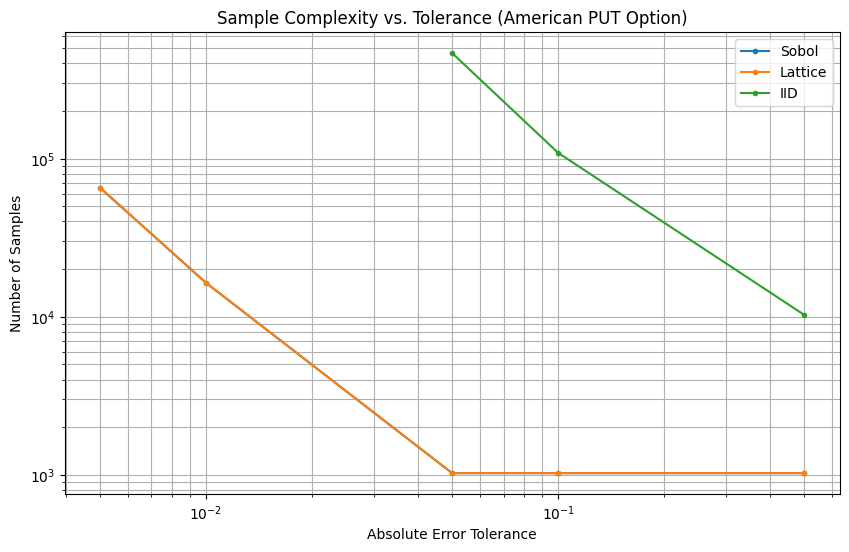

In [11]:
plt.figure(figsize=(10,6))
plt.loglog(tol_vec, nSobol_required, '.-', label="Sobol")
plt.loglog(tol_vec, nLattice_required, '.-', label="Lattice")
plt.loglog(tol_vec, nIID_required, '.-', label="IID")

plt.xlabel("Absolute Error Tolerance")
plt.ylabel("Number of Samples")
plt.title("Sample Complexity vs. Tolerance (American PUT Option)")
plt.legend()
plt.grid(True, which="both")
plt.show()

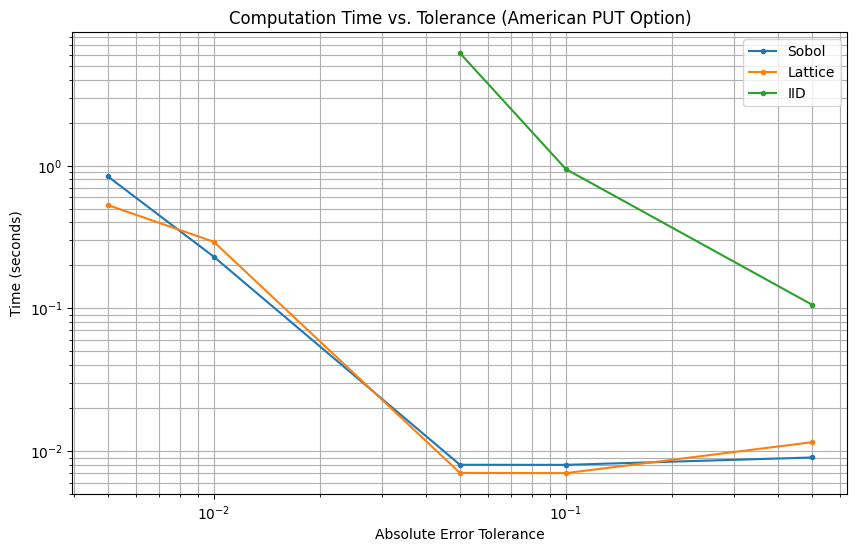

In [12]:
plt.figure(figsize=(10,6))
plt.loglog(tol_vec, tSobol_required, '.-', label="Sobol")
plt.loglog(tol_vec, tLattice_required, '.-', label="Lattice")
plt.loglog(tol_vec, tIID_required, '.-', label="IID")

plt.xlabel("Absolute Error Tolerance")
plt.ylabel("Time (seconds)")
plt.title("Computation Time vs. Tolerance (American PUT Option)")
plt.legend()
plt.grid(True, which="both")
plt.show()


Tolerance index 0, abs_tol = 0.5

Tolerance index 1, abs_tol = 0.1

Tolerance index 2, abs_tol = 0.05

Tolerance index 3, abs_tol = 0.01

Tolerance index 4, abs_tol = 0.005

========== RESULTS ==========
Sobol price: 10.676854791129308
Lattice price: 9.083280409393964
IID price: 11.908209607076964


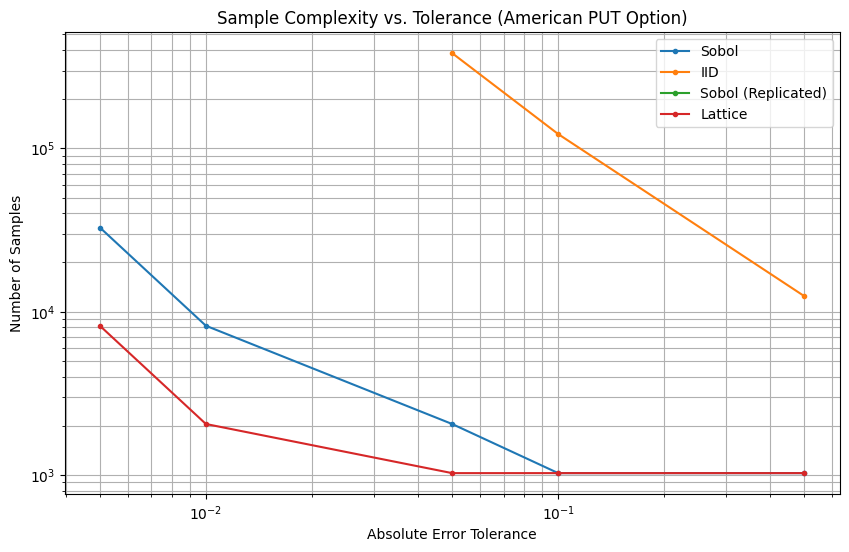

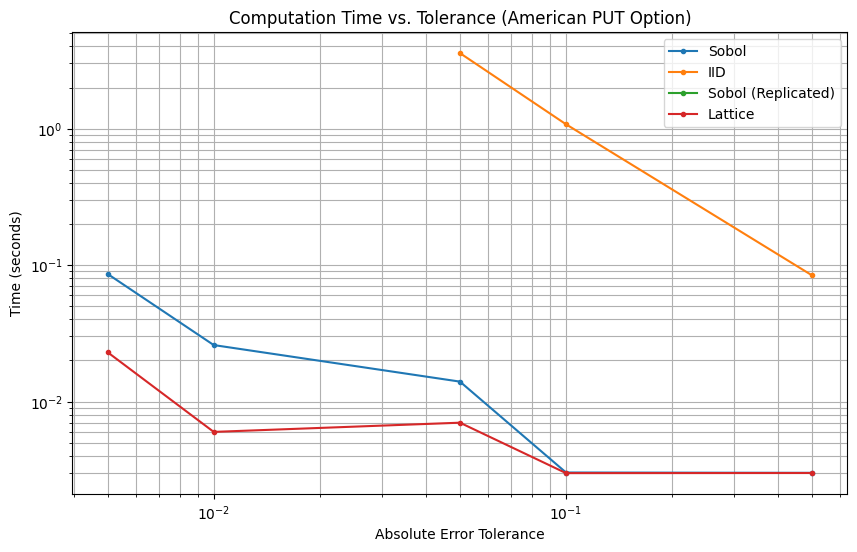

In [14]:
from qmcpy.discrete_distribution import Sobol, IIDStdUniform, Halton, Lattice
from qmcpy.stopping_criterion import CubQMCSobolG, CubMCG, CubQMCLatticeG
from qmcpy.integrand.financial_option import FinancialOption

import numpy as np
import matplotlib.pyplot as plt

# ================================
# PROBLEM PARAMETERS
# ================================
d = 32
vol = 0.2
initPrice = 100
strike = 110
interest = 0.05
callput = "PUT"        # American PUT
t_final = 1.0

# ================================
# SAMPLERS
# ================================
SobolPoints   = Sobol(dimension=d)
IIDPoints     = IIDStdUniform(dimension=d)
HaltonPoints  = Halton(dimension=d)
SobolPointsRep = Sobol(dimension=d, replications=16)
LatticePoints = Lattice(dimension=d)


AmericanSobol = FinancialOption(
    SobolPoints,
    option="EUROPEAN",
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

AmericanIID = FinancialOption(
    IIDPoints,
    option="AMERICAN",
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

AmericanHalton = FinancialOption(
    HaltonPoints,
    option="AMERICAN",
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

AmericanSobolRep = FinancialOption(
    SobolPointsRep,
    option="AMERICAN",
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

AmericanLattice = FinancialOption(
    LatticePoints,
    option="ASIAN",
    call_put=callput,
    volatility=vol,
    start_price=initPrice,
    strike_price=strike,
    interest_rate=interest,
    t_final=t_final
)

# ================================
# TOLERANCES
# ================================
tol_vec = np.array([0.5, 0.1, 0.05, 0.01, 0.005])

nSobol_required   = np.zeros_like(tol_vec)
tSobol_required   = np.zeros_like(tol_vec)
nIID_required     = np.zeros_like(tol_vec)
tIID_required     = np.zeros_like(tol_vec)
nHalton_required  = np.zeros_like(tol_vec)
tHalton_required  = np.zeros_like(tol_vec)
nSobolRep_required  = np.zeros_like(tol_vec)
tSobolRep_required  = np.zeros_like(tol_vec)
nLattice_required = np.zeros_like(tol_vec)
tLattice_required = np.zeros_like(tol_vec)


for ii, abs_tol in enumerate(tol_vec):
    print(f"\nTolerance index {ii}, abs_tol = {abs_tol}")

    # Sobol
    SobolPrice, data = CubQMCSobolG(AmericanSobol, abs_tol=abs_tol).integrate()
    nSobol_required[ii] = data.n_total
    tSobol_required[ii] = data.time_integrate

    # Lattice
    LatticePrice, data = CubQMCLatticeG(AmericanLattice, abs_tol=abs_tol).integrate()
    nLattice_required[ii] = data.n_total
    tLattice_required[ii] = data.time_integrate

    # IID (only for coarse tolerances)
    if abs_tol >= 0.05:
        IIDPrice, data = CubMCG(AmericanIID, abs_tol=abs_tol).integrate()
        nIID_required[ii] = data.n_total
        tIID_required[ii] = data.time_integrate
    else:
        nIID_required[ii] = np.nan
        tIID_required[ii] = np.nan

# ================================
# RESULTS
# ================================
print("\n========== RESULTS ==========")
print("Sobol price:", SobolPrice)
print("Lattice price:", LatticePrice)
print("IID price:", IIDPrice if np.any(~np.isnan(nIID_required)) else "N/A")

# ================================
# PLOTS: SAMPLE COUNTS
# ================================
plt.figure(figsize=(10,6))
plt.loglog(tol_vec, nSobol_required, '.-', label="Sobol")
plt.loglog(tol_vec, nIID_required, '.-', label="IID")
plt.loglog(tol_vec, nSobolRep_required, '.-', label="Sobol (Replicated)")
plt.loglog(tol_vec, nLattice_required, '.-', label="Lattice")
plt.xlabel("Absolute Error Tolerance")
plt.ylabel("Number of Samples")
plt.title("Sample Complexity vs. Tolerance (American PUT Option)")
plt.legend()
plt.grid(True, which="both")
plt.show()

# ================================
# PLOTS: TIME
# ================================
plt.figure(figsize=(10,6))
plt.loglog(tol_vec, tSobol_required, '.-', label="Sobol")
plt.loglog(tol_vec, tIID_required, '.-', label="IID")
plt.loglog(tol_vec, tSobolRep_required, '.-', label="Sobol (Replicated)")
plt.loglog(tol_vec, tLattice_required, '.-', label="Lattice")
plt.xlabel("Absolute Error Tolerance")
plt.ylabel("Time (seconds)")
plt.title("Computation Time vs. Tolerance (American PUT Option)")
plt.legend()
plt.grid(True, which="both")
plt.show()

# import qmcpy
# print(qmcpy.__file__)